# Behavioural sequence analysis
This script is used to check the behavioural sequences and quickly see what they look like
The existing code can easily duplicated in additional cells to check other aspects of the 'parameters_per_stimuli' file

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

import seaborn as sns # Loads in the theme
#pd.set_option('display.max_rows', None)

In [2]:
# Make output folder if non-existent
output_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/sequences'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Load the path and read the CSV
subject_id = [62]
session_number = [1]

sequence_path = os.path.join('/Volumes', 'project', '3025011.02', 'Approach-Avoidance_Reinforcement_Learning_task', 'sequences', f'parameters_per_stimuli_sub-{subject_id[0]:003}_session-{session_number[0]:02}.csv')
sequence_dataframe = pd.read_csv(sequence_path, sep=';')

# Adding a helper column 'entry' to keep track of the count of each type
sequence_dataframe['trial'] = sequence_dataframe.groupby('stimuli_type').cumcount()
unique_stimuli_types = sorted(sequence_dataframe['stimuli_type'].unique())

# Pivot the DataFrame using the new 'entry' column as the index
probability_dataframe_pivoted = sequence_dataframe.pivot(index = 'trial', columns = 'stimuli_type', values = 'probability_condition')

## Probability sequence
### Plot all probability sequences together
As seen in Ly's paper from 2014

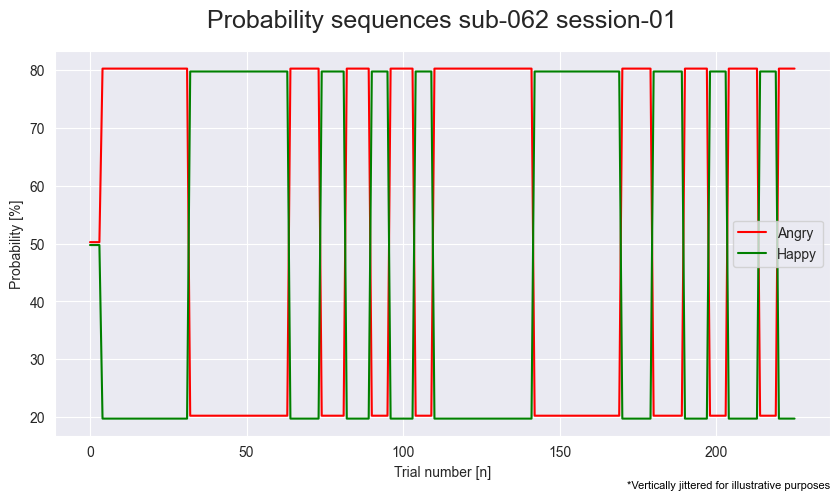

In [4]:
# Jitter vertically to make the lines easier to read when overlapping
if probability_dataframe_pivoted.iloc[6, 0] > probability_dataframe_pivoted.iloc[6, 1]:
    jitter_strength = [0.25, -0.25]
else:
    jitter_strength = [-0.25, 0.25]

stimuli_type_names = ['Angry','Happy']
group_colours = ['red','green']
note = '*Vertically jittered for illustrative purposes'
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(10, 5))
for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value] + jitter_strength[index]
    plt.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value-1])
plt.title(f'Probability sequences sub-{subject_id[0]:003} session-{session_number[0]:02}', fontsize=18, y=1.04)
plt.xlabel('Trial number [n]')
plt.ylabel('Probability [%]')
plt.legend()
plt.text(1, -0.14, note, transform=ax.transAxes, horizontalalignment='right', verticalalignment='bottom',
         fontsize=8, color='black')
plt.savefig(os.path.join(output_dir, f'probability_sequence_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()

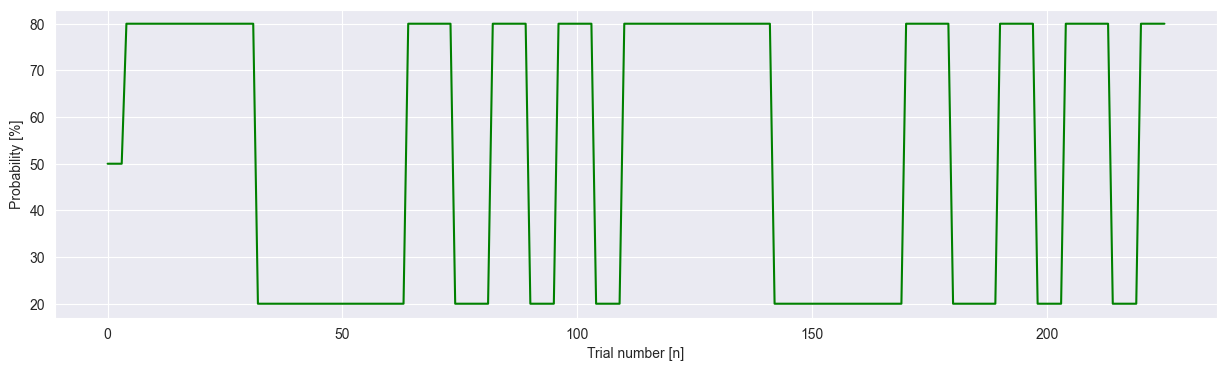

In [5]:
stimuli_type_names = ['Angry','Happy']
group_colours = ['green']
note = '*Vertically jittered for illustrative purposes'
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(15, 4))
column_data = probability_dataframe_pivoted[1]
plt.plot(column_data, label=stimuli_type_names[1-1], color=group_colours[1-1])
plt.xlabel('Trial number [n]')
plt.ylabel('Probability [%]')
plt.savefig(os.path.join(output_dir, f'poster_probability_sequence_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()